# Notebook 03 — Band Structure with Cosine Potential

Band structure along $\Gamma \to X \to M \to \Gamma$ with $V(\mathbf{r}) = -V_0 [\cos(2\pi x) + \cos(2\pi y)]$ at $V_0 = 1.0$. Gaps open at zone boundaries where degenerate free-electron bands are coupled by a non-zero Fourier component of the potential. At X, the relevant coupling is $V_{(\pm 1, 0)} = -V_0/2$, so the gap is
$$\Delta(X) = 2 \, |V_{(1, 0)}| = V_0.$$
The side-by-side panel compares $V_0 = 0$ (left) and $V_0 = 1$ (right), and the gap at X is annotated explicitly on the right panel.

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.lattice import high_symmetry_path
from src.hamiltonian import cosine_potential
from src.bands import compute_bands_along_path

FIG_DIR = ROOT / "figures" / "03_with_potential"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_CUT = 3
N_PER_SEG = 120
N_BANDS_PLOT = 8
V_0_VALUES = [0.0, 1.0]
PATH_NODES = high_symmetry_path()
NODE_LABELS = [r"$\Gamma$", "X", "M", r"$\Gamma$"]

In [2]:
results = {}
for V_0 in V_0_VALUES:
    V_func = cosine_potential(V_0=V_0)
    k_dist, energies, node_dists = compute_bands_along_path(
        PATH_NODES, N_PER_SEG, V_func, N_CUT
    )
    results[V_0] = (k_dist, energies, node_dists)

# Index of X along the sampled path: it is the second node of the path,
# located at node_dists[1]. argmin(|k_dist - node_dists[1]|) is robust to
# any future change in how points are deduplicated.
k_dist0, _, node_dists0 = results[V_0_VALUES[0]]
X_idx = int(np.argmin(np.abs(k_dist0 - node_dists0[1])))
print(f"X-point index along path: {X_idx}  (k_dist[X_idx] = {k_dist0[X_idx]:.4f}, node_dists[1] = {node_dists0[1]:.4f})")

print("\nGap at X (band 2 - band 1):")
for V_0 in V_0_VALUES:
    E = results[V_0][1]
    gap_num = E[X_idx, 1] - E[X_idx, 0]
    gap_ana = V_0  # analytic prediction = V_0
    print(f"  V_0 = {V_0:.2f}  numerical = {gap_num:.6f}  analytic = {gap_ana:.6f}  "
          f"diff = {gap_num - gap_ana:+.3e}")

X-point index along path: 119  (k_dist[X_idx] = 3.1416, node_dists[1] = 3.1416)

Gap at X (band 2 - band 1):
  V_0 = 0.00  numerical = 0.000000  analytic = 0.000000  diff = +0.000e+00
  V_0 = 1.00  numerical = 0.999960  analytic = 1.000000  diff = -4.010e-05
  V_0 = 5.00  numerical = 4.994993  analytic = 5.000000  diff = -5.007e-03


/var/folders/30/2dmkn_6j61q38qz44ytpvznc0000gn/T/ipykernel_40332/87315170.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


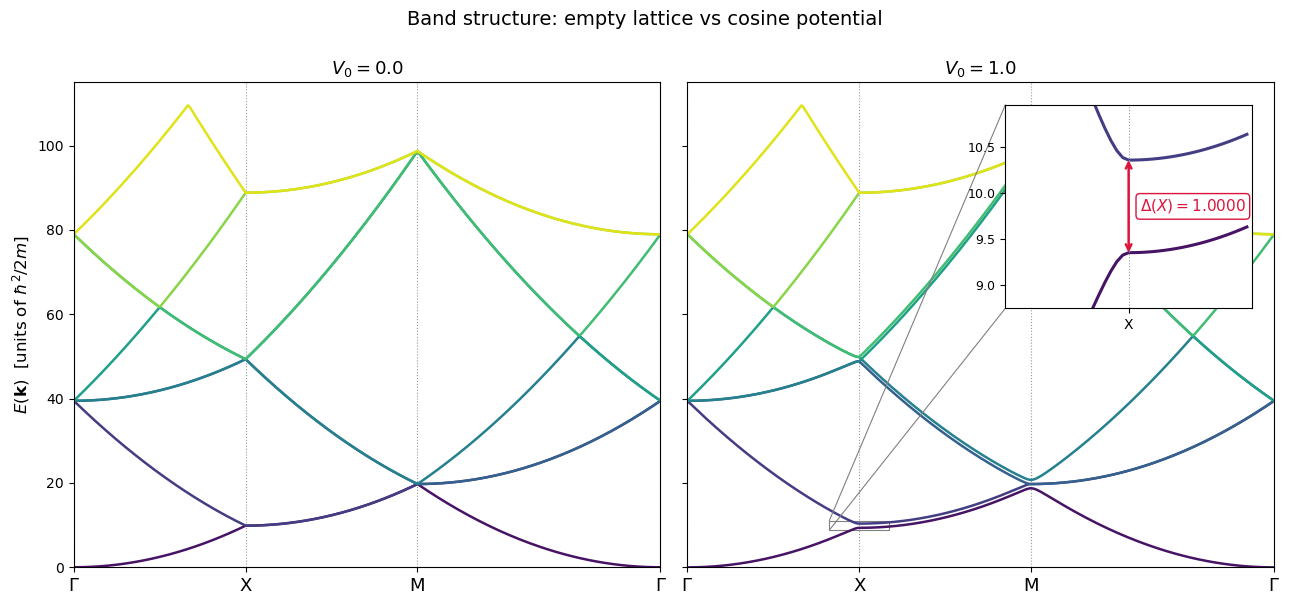

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, axes = plt.subplots(1, 2, figsize=(13.0, 6.0), sharey=True)

colors = plt.cm.viridis(np.linspace(0.05, 0.95, N_BANDS_PLOT))
y_max = max(np.max(results[V][1][:, N_BANDS_PLOT - 1]) for V in V_0_VALUES) * 1.05

for ax, V_0 in zip(axes, V_0_VALUES):
    k_dist, E, node_dists = results[V_0]

    for n in range(N_BANDS_PLOT):
        ax.plot(k_dist, E[:, n], color=colors[n], linewidth=1.8, zorder=2)

    for x in node_dists:
        ax.axvline(x, color="0.6", linestyle=":", linewidth=0.8, zorder=0)

    ax.set_xticks(node_dists)
    ax.set_xticklabels(NODE_LABELS, fontsize=13)
    ax.set_xlim(k_dist[0], k_dist[-1])
    ax.set_ylim(0, y_max)
    ax.set_title(f"$V_0 = {V_0:.1f}$", fontsize=13)

axes[0].set_ylabel(r"$E(\mathbf{k})$  [units of $\hbar^2/2m$]", fontsize=12)

# --- Inset zoom on the X-point gap in the V_0 = 1 panel. ---
ax_right = axes[1]
k_dist_r, E_pot, node_dists_r = results[1.0]
x_at_X = node_dists_r[1]
y_low = E_pot[X_idx, 0]
y_high = E_pot[X_idx, 1]
gap = y_high - y_low

# Inset axes anchored in figure-fraction coords of the right panel.
ax_in = inset_axes(ax_right, width="42%", height="42%", loc="upper right",
                   borderpad=1.6)

half_window = 0.55  # k-distance window around X for the inset
zoom_pad = 0.6      # vertical padding around the gap
zoom_xmin, zoom_xmax = x_at_X - half_window, x_at_X + half_window
zoom_ymin, zoom_ymax = y_low - zoom_pad, y_high + zoom_pad

# Mask path indices that fall inside the zoom window so the inset plot is fast.
mask = (k_dist_r >= zoom_xmin) & (k_dist_r <= zoom_xmax)
for n in range(2):
    ax_in.plot(k_dist_r[mask], E_pot[mask, n], color=colors[n], linewidth=2.2)

ax_in.set_xlim(zoom_xmin, zoom_xmax)
ax_in.set_ylim(zoom_ymin, zoom_ymax)
ax_in.axvline(x_at_X, color="0.6", linestyle=":", linewidth=0.8)
ax_in.set_xticks([x_at_X])
ax_in.set_xticklabels(["X"], fontsize=10)
ax_in.tick_params(axis="y", labelsize=9)
ax_in.set_facecolor("white")

# Gap arrow + label inside the inset.
ax_in.annotate(
    "", xy=(x_at_X, y_high), xytext=(x_at_X, y_low),
    arrowprops=dict(arrowstyle="<->", color="crimson", lw=1.8, shrinkA=0, shrinkB=0),
)
ax_in.text(
    x_at_X + 0.05, (y_low + y_high) / 2,
    rf"$\Delta(X) = {gap:.4f}$",
    fontsize=11, color="crimson", va="center", ha="left",
    bbox=dict(facecolor="white", edgecolor="crimson", boxstyle="round,pad=0.25"),
)

# Draw lines connecting the inset to the zoomed region on the parent axes.
mark_inset(ax_right, ax_in, loc1=2, loc2=3, fc="none", ec="0.5", lw=0.8)

fig.suptitle("Band structure: empty lattice vs cosine potential", fontsize=14, y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure_03_bands_with_potential.png", dpi=180, bbox_inches="tight")
plt.show()